# REmoving the overlap error

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rcParams
from scipy.signal import savgol_filter, find_peaks, correlate
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit, minimize
from sklearn.metrics import mean_squared_error, r2_score
import pywt
from datetime import datetime
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.stats import linregress
from scipy.stats import pearsonr
from scipy.constants import R
from matplotlib.patheffects import withStroke
from scipy.ndimage import gaussian_filter1d, uniform_filter1d
import seaborn as sns

from matplotlib import rcParams
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

#aesthetics
# aesthetics & fonts
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
dpi = 900

def style_axes(ax, xlabel, ylabel, x_major=None, y_major=None):
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.2, labelsize=14)
    ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)
    ax.minorticks_on()
    if x_major is not None:
        ax.xaxis.set_major_locator(MultipleLocator(x_major))
    if y_major is not None:
        ax.yaxis.set_major_locator(MultipleLocator(y_major))



count of -1 in there is:  0
count of -2 in there is:  89
count of 0 in there is:  0


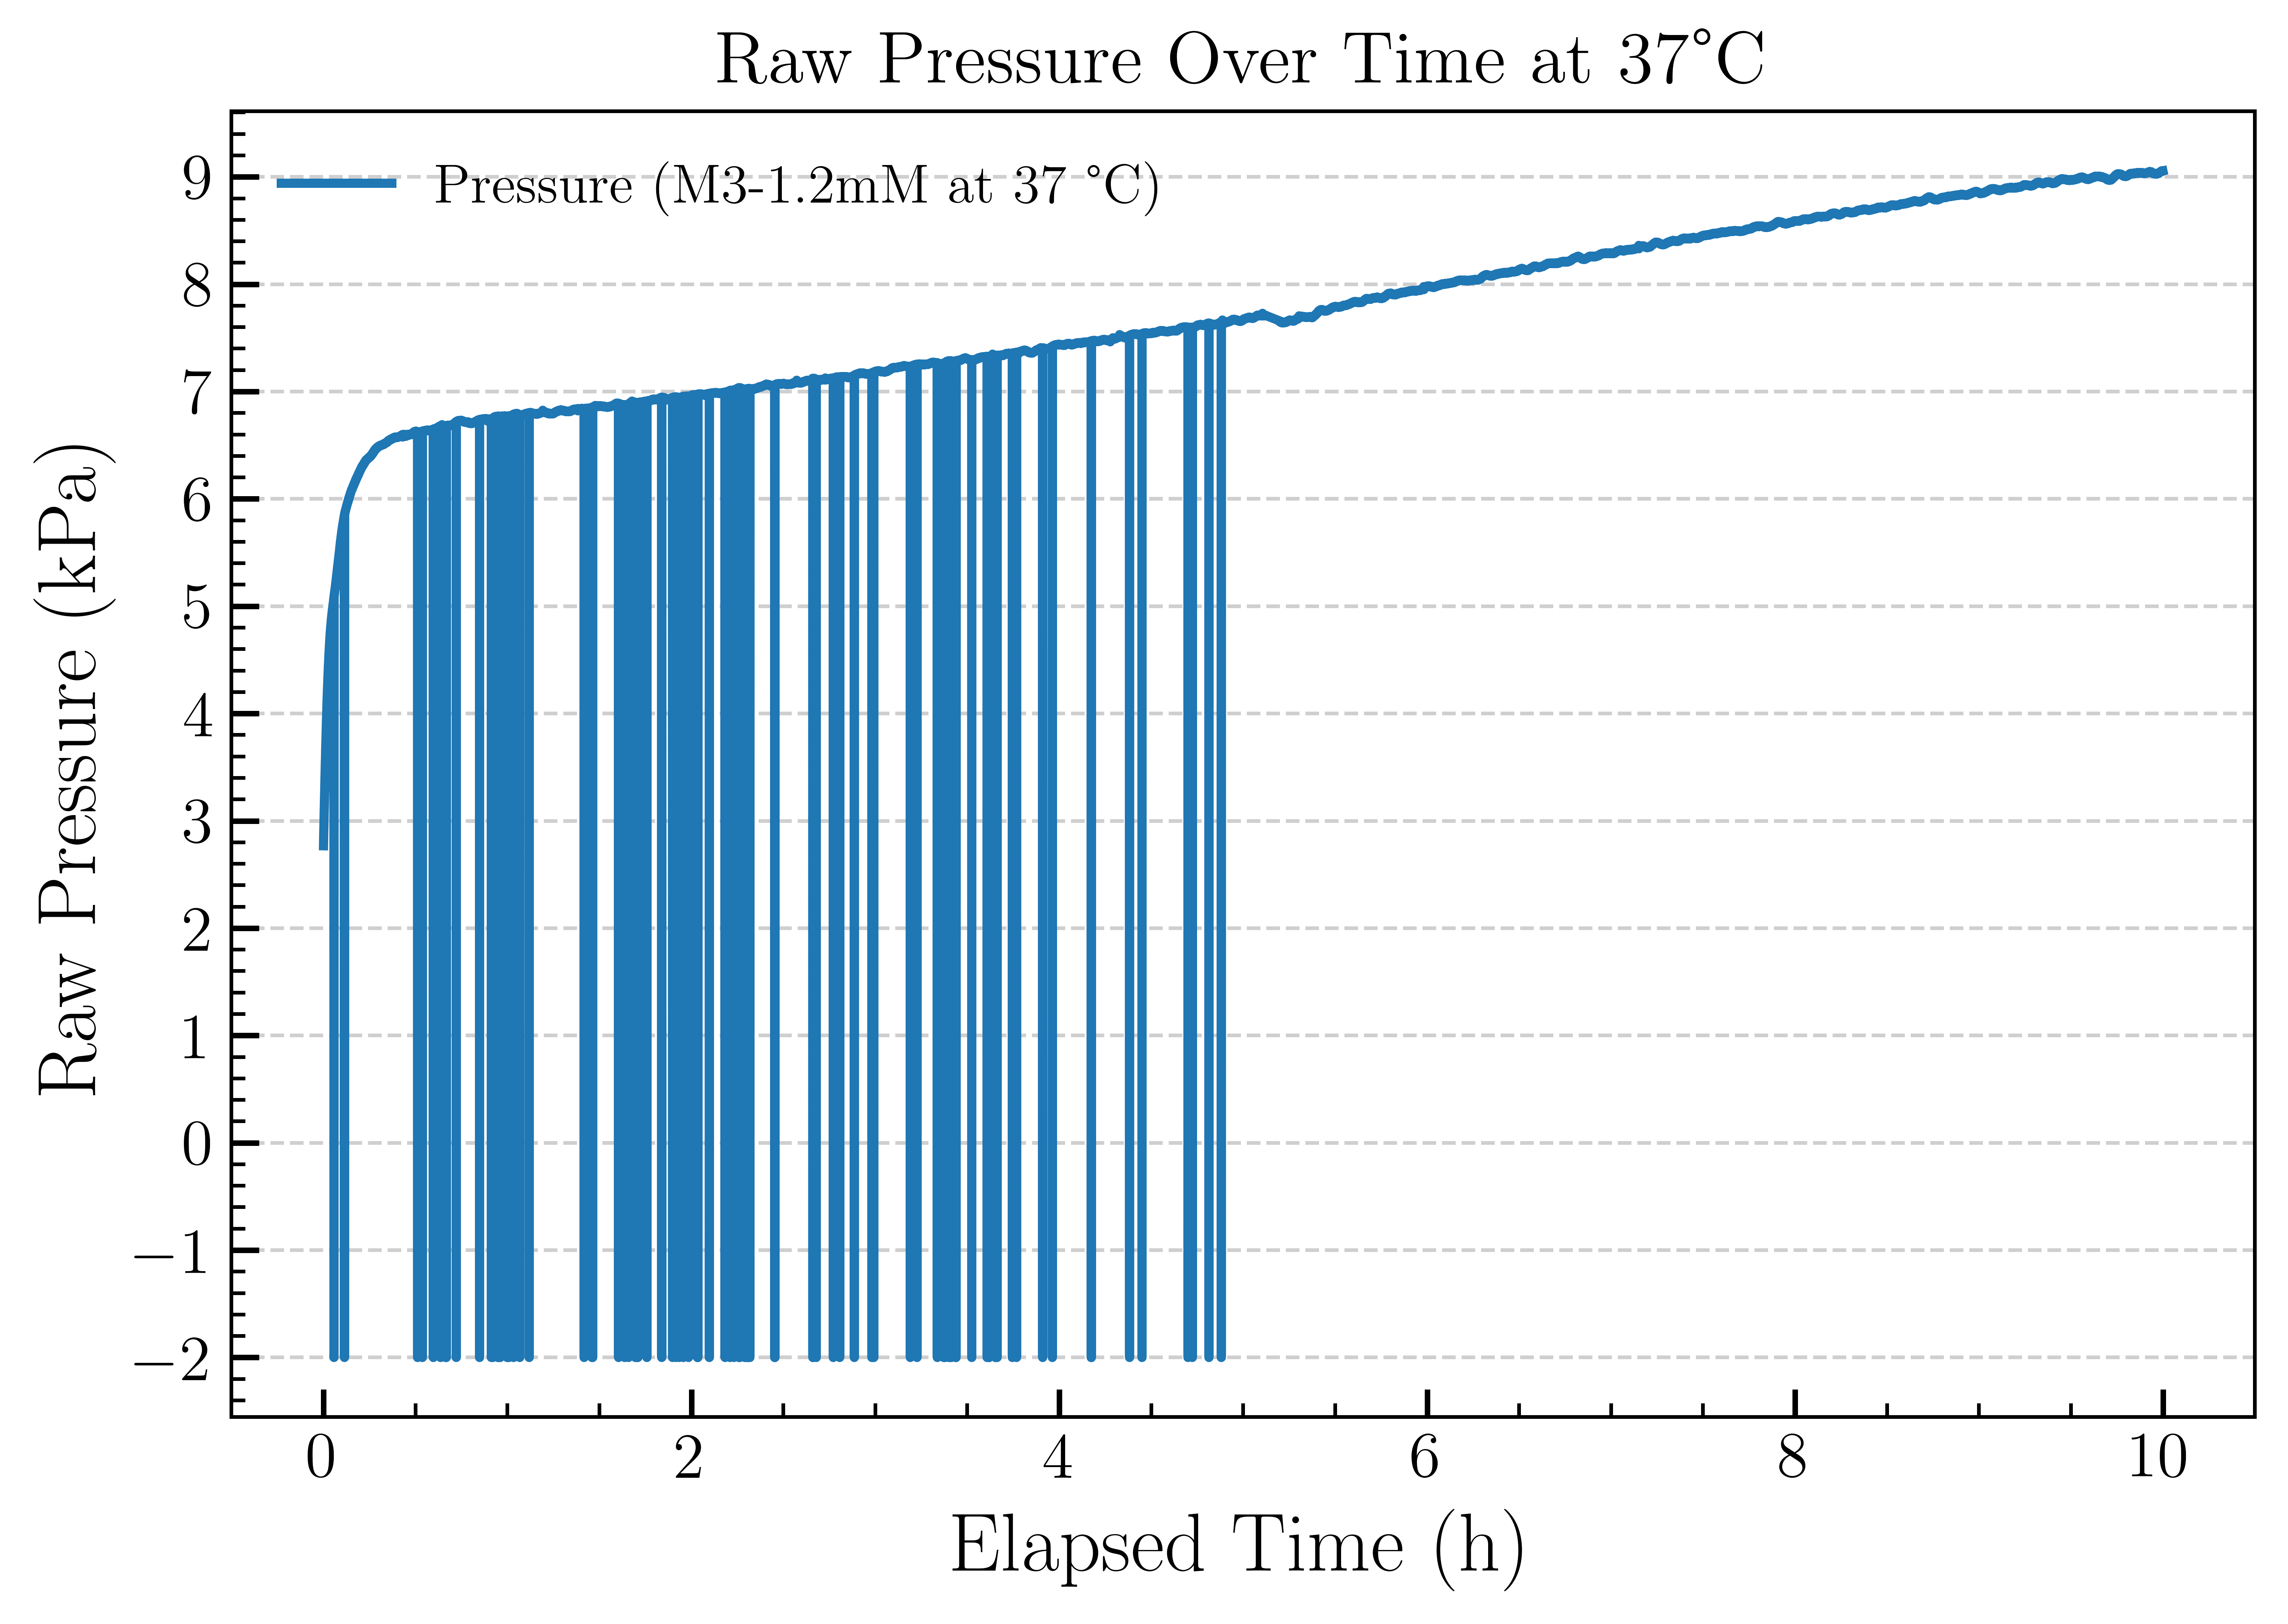

In [11]:

main_path = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Sample_M3\M3_1.2mM\Pressure_37deg\raw_meas\merged_pressure_log.csv"

# Load data
df_filtered = pd.read_csv(main_path)


count = (df_filtered["ABP2-Sch1 (kPa)"] == -2).sum()
count1 = (df_filtered["ABP2-Sch1 (kPa)"] == -1).sum()
count0 = (df_filtered["ABP2-Sch1 (kPa)"] == 0).sum()
print("count of -1 in there is: ", count1)       

print("count of -2 in there is: ", count)
print("count of 0 in there is: ", count0)        

df_time = df_filtered[df_filtered["Elapsed Time (hours)"] < 10.0]         


fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_time["Elapsed Time (hours)"],
         df_time["ABP2-Sch1 (kPa)"],
         lw=2.0, color="tab:blue",
         label=r'Pressure (M3-1.2mM at 37 °C)')

ax1.set_title('Raw Pressure Over Time at 37°C', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Raw Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.show()

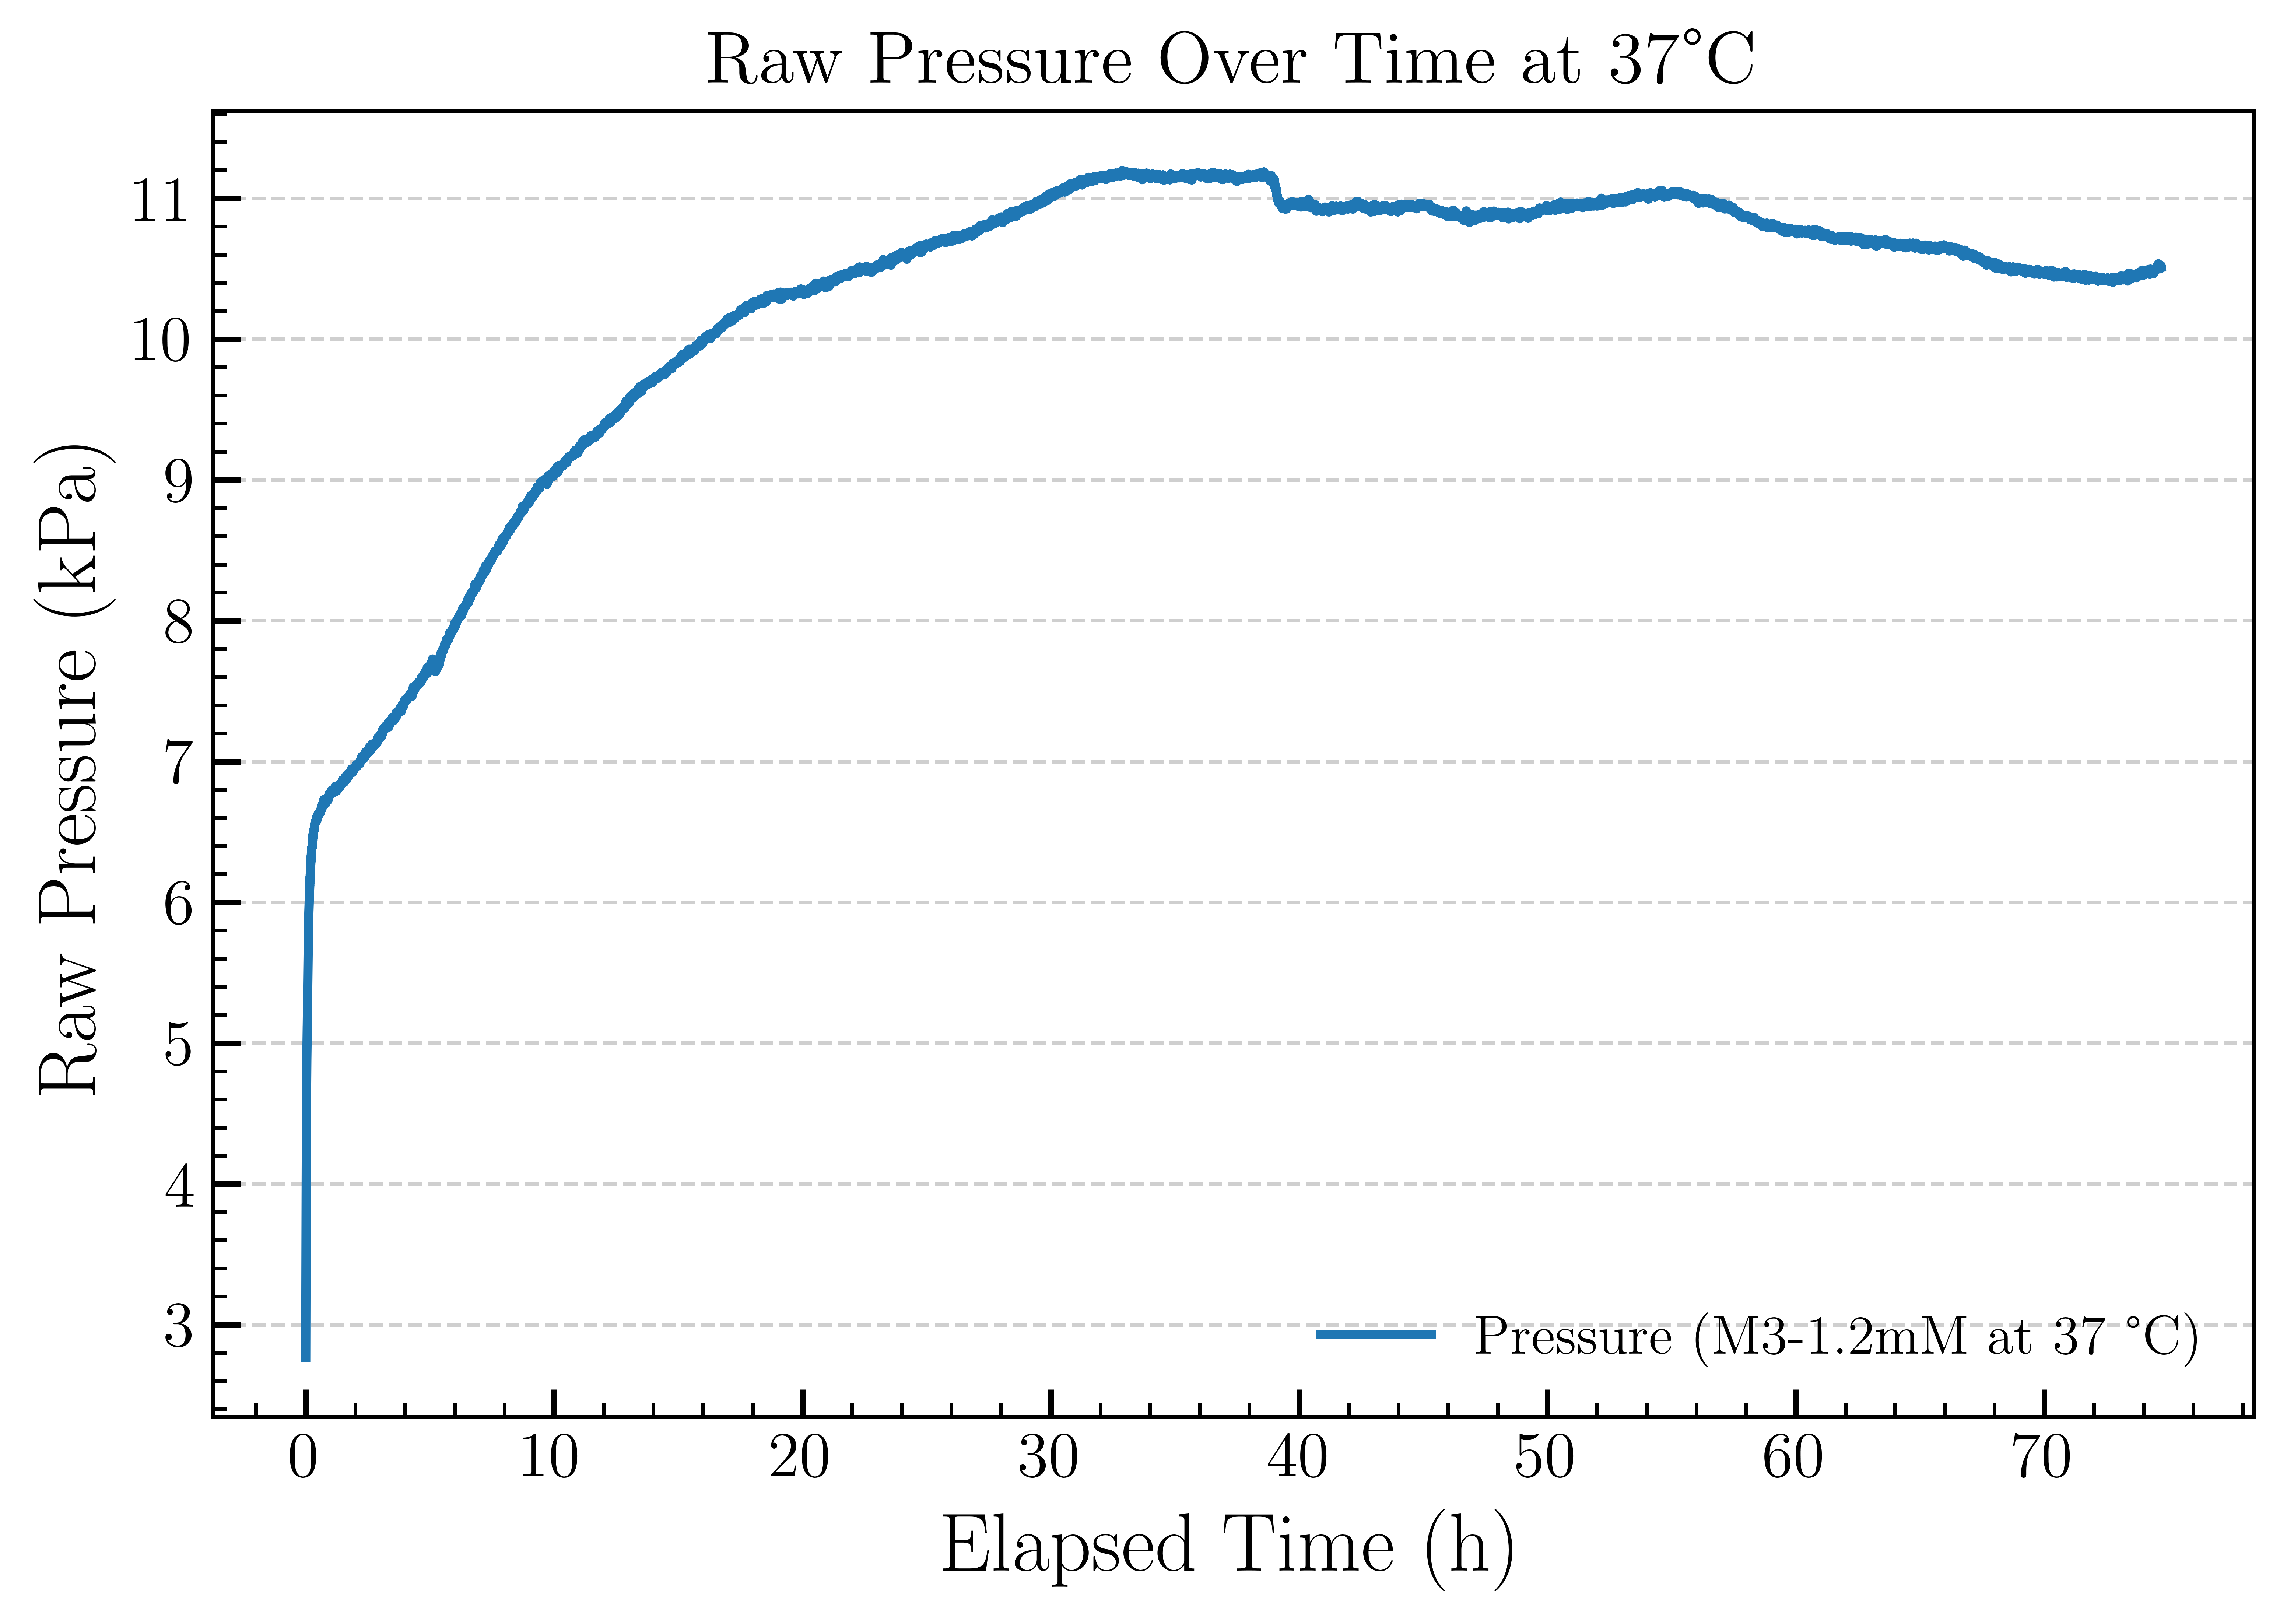

In [ ]:
# drop rows with -2 

df_dropped = df_filtered[df_filtered["ABP2-Sch1 (kPa)"] != -2]


fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_dropped["Elapsed Time (hours)"],
         df_dropped["ABP2-Sch1 (kPa)"],
         lw=2.0, color="tab:blue",
         label=r'Pressure (M3-1.2mM at 37 °C)')

ax1.set_title('Raw Pressure Over Time at 37°C', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Raw Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.show()

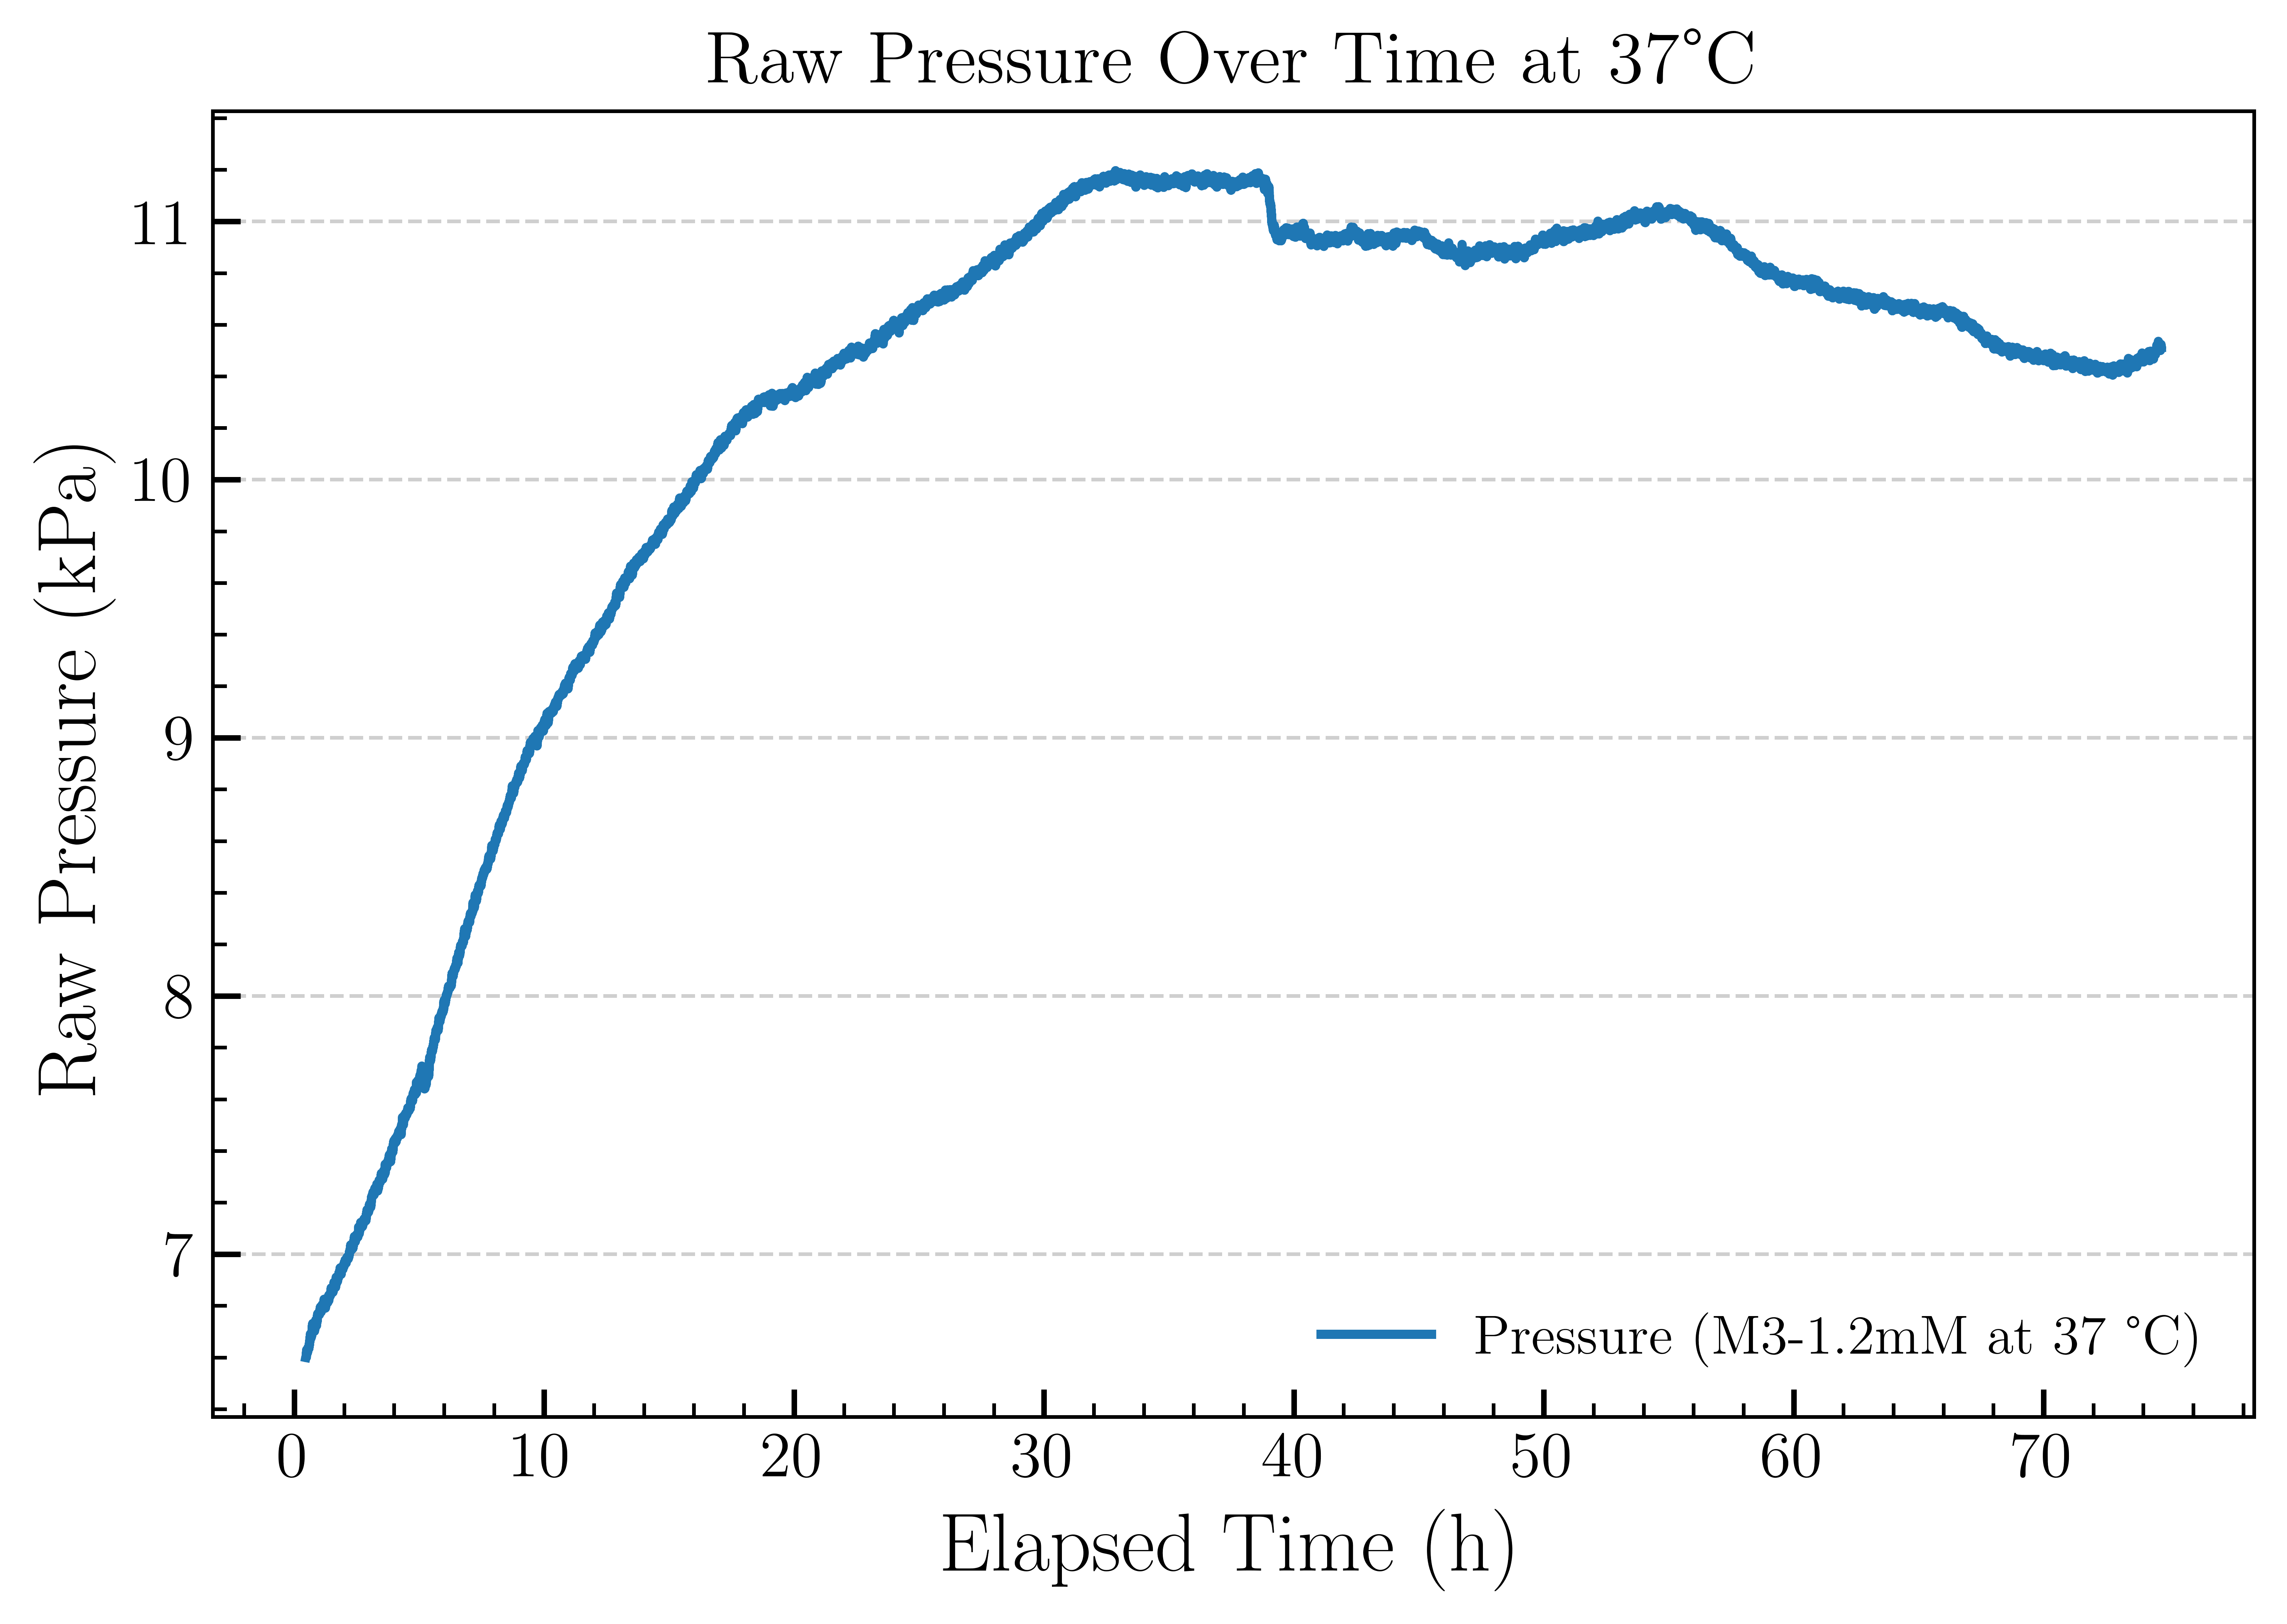

In [26]:
df_sensor = df_dropped[df_dropped["ABP2-Sch1 (kPa)"] > 6.6]



pd.DataFrame.to_csv(df_sensor, r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Sample_M3\M3_1.2mM\Pressure_37deg\raw_meas\raw_negative_dropped.csv", index=False)

fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_sensor["Elapsed Time (hours)"],
         df_sensor["ABP2-Sch1 (kPa)"],
         lw=2.0, color="tab:blue",
         label=r'Pressure (M3-1.2mM at 37 °C)')

ax1.set_title('Raw Pressure Over Time at 37°C', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Raw Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.show()

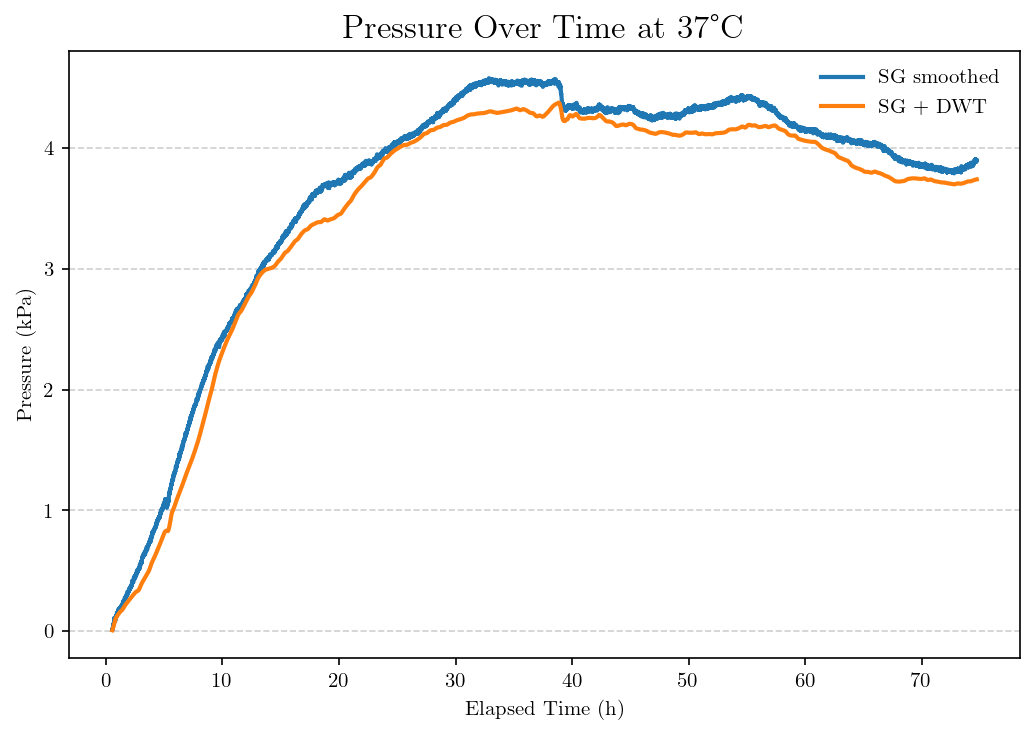

In [ ]:

from matplotlib.pyplot import ylabel

raw_path = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Sample_M3\M3_1.2mM\Pressure_37deg\raw_meas\raw_negative_dropped.csv"
main_path = r"C:\Users\chand\Documents\GitHub\Thesis\M3_1.2mM_37deg_pressure_o2_release.csv"

# Load data
df_main = pd.read_csv(main_path)
df_raw = pd.read_csv(raw_path)
  
fig, ax = plt.subplots(figsize=(7,5), dpi=150)

# check your column names in df_main
sg_col  = "Smoothed pressure from just SG (kPa)"
dwt_col = "DWT denoised pressure (kPa)"   # adjust if different
t_main  = df_main["Time (h)"]

ax.plot(t_main, df_main[sg_col],  lw=2.0, label="SG smoothed")
ax.plot(t_main, df_main[dwt_col], lw=2.0, label="SG + DWT")

# # raw uses its own time axis
# ax.plot(df_raw["Elapsed Time (hours)"],
#         df_raw["ABP2-Sch1 (kPa)"], lw=1.5, label="Raw")

ax.set_title("Pressure Over Time at 37°C", fontsize=16)
ax.set_xlabel("Elapsed Time (h)")
ax.set_ylabel("Pressure (kPa)")
ax.legend(frameon=False)
ax.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


# fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
# ax1.plot(df_main["Time (h)"],
#          df_main["Smoothed pressure from just SG (kPa)"],
#          df_main["DWT denoised pressure (kPa)"],
#          df_raw["ABP2-Sch1 (kPa)"],
#          lw=2.0, color="tab:blue",
#          label=r'Pressure (M3-1.2mM at 37 °C)')

# ax1.set_title('Raw Pressure Over Time at 37°C', fontsize=16)
# style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="SG smoothed", ylabel="DWT", ylabel = "Raw", y_major=1.0)
# ax1.legend(frameon=False, fontsize=12, loc="best")
# plt.tight_layout()
# plt.show()

# DWT is an overkill

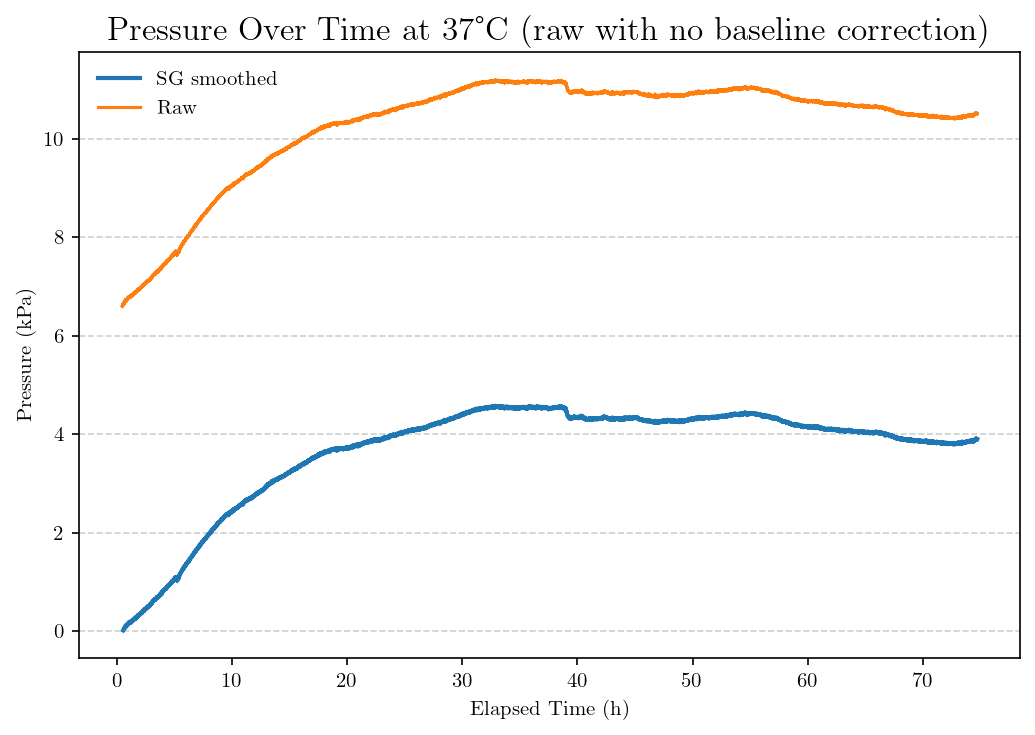

In [59]:




raw_path = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Sample_M3\M3_1.2mM\Pressure_37deg\raw_meas\raw_negative_dropped.csv"
main_path = r"C:\Users\chand\Documents\GitHub\Thesis\M3_1.2mM_37deg_pressure_o2_release.csv"

# Load data
df_main = pd.read_csv(main_path)
df_raw = pd.read_csv(raw_path)
  
fig, ax = plt.subplots(figsize=(7,5), dpi=150)

# check your column names in df_main
sg_col  = "Smoothed pressure from just SG (kPa)"
t_main  = df_main["Time (h)"]
t_raw = df_raw["Elapsed Time (hours)"]
raw_abp2 = df_raw["ABP2-Sch1 (kPa)"]

ax.plot(t_main, df_main[sg_col],  lw=2.0, label="SG smoothed")
ax.plot(t_raw, raw_abp2, lw=1.5, label="Raw")



ax.set_title("Pressure Over Time at 37°C (raw with no baseline correction)", fontsize=16)
ax.set_xlabel("Elapsed Time (h)")
ax.set_ylabel("Pressure (kPa)")
ax.legend(frameon=False)
ax.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


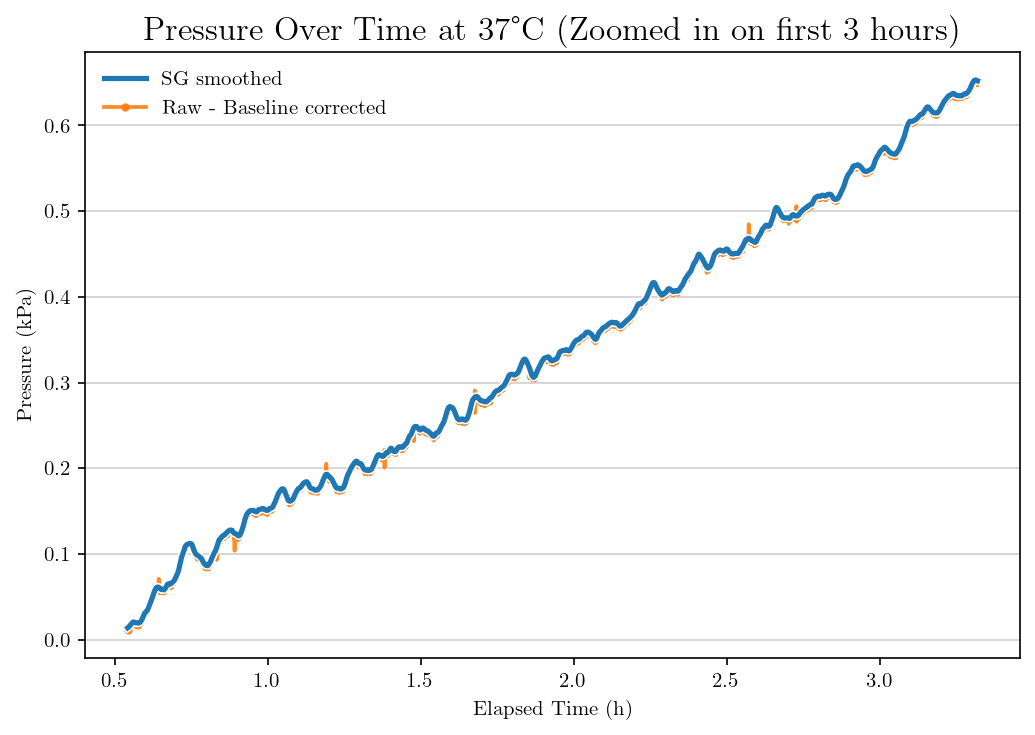

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

raw_path  = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Sample_M3\M3_1.2mM\Pressure_37deg\raw_meas\raw_negative_dropped.csv"
main_path = r"C:\Users\chand\Documents\GitHub\Thesis\M3_1.2mM_37deg_pressure_o2_release.csv"

df_main = pd.read_csv(main_path)
df_raw  = pd.read_csv(raw_path)

sg_col = "Smoothed pressure from just SG (kPa)"
t_main = df_main["Time (h)"].values
sg     = df_main[sg_col].values

t_raw    = df_raw["Elapsed Time (hours)"].values

raw_abp2 = df_raw["ABP2-Sch1 (kPa)"].values

# Baseline raw by first 5 minutes
baseline_end = t_raw.min() + 5/60.0
mask_base    = t_raw <= baseline_end
raw_corr     = raw_abp2 - raw_abp2[mask_base].mean()

# Interpolate raw onto SG time grid (overlap only)
mask_overlap = (t_main >= t_raw.min()) & (t_main <= t_raw.max())
t_plot       = t_main[mask_overlap]
sg_plot      = sg[mask_overlap]
raw_plot     = np.interp(t_plot, t_raw, raw_corr)

fig, ax = plt.subplots(figsize=(7,5), dpi=150)

# SG: dashed + white outline so it "pops" over the raw line
ax.plot(
    t_plot[:10000], sg_plot[:10000], lw=2.5, linestyle="-", color="tab:blue", label="SG smoothed",
    zorder=3, path_effects=[pe.Stroke(linewidth=4, foreground="white"), pe.Normal()]
)

# Raw: solid + semi-transparent + markers every N points
ax.plot(
    t_plot[:10000], raw_plot[:10000], lw=1.8, color="tab:orange", alpha=0.9, label="Raw - Baseline corrected",
    marker="o", markevery=max(1, len(t_plot)//60), ms=3, zorder=2
)

ax.set_title("Pressure Over Time at 37°C (Zoomed in on first 3 hours)", fontsize=16)
ax.set_xlabel("Elapsed Time (h)")
ax.set_ylabel("Pressure (kPa)")
ax.grid(True, axis="y", linestyle="-", alpha=0.6)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


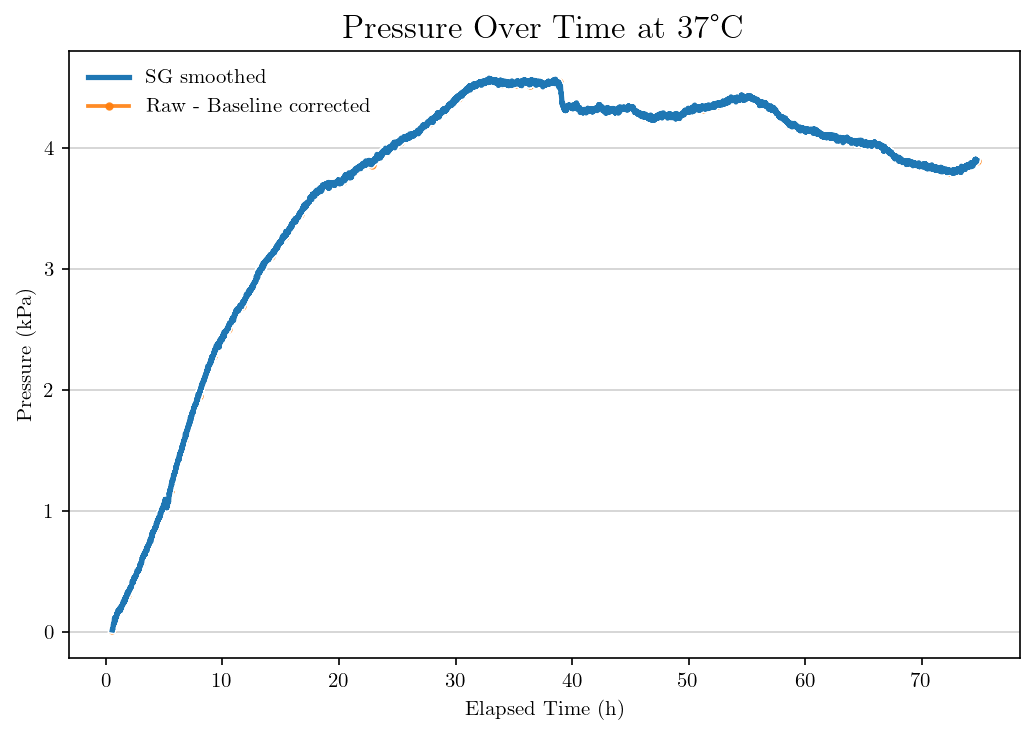

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

raw_path  = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Sample_M3\M3_1.2mM\Pressure_37deg\raw_meas\raw_negative_dropped.csv"
main_path = r"C:\Users\chand\Documents\GitHub\Thesis\M3_1.2mM_37deg_pressure_o2_release.csv"

df_main = pd.read_csv(main_path)
df_raw  = pd.read_csv(raw_path)

sg_col = "Smoothed pressure from just SG (kPa)"
t_main = df_main["Time (h)"].values
sg     = df_main[sg_col].values

t_raw    = df_raw["Elapsed Time (hours)"].values

raw_abp2 = df_raw["ABP2-Sch1 (kPa)"].values

# Baseline raw by first 5 minutes
baseline_end = t_raw.min() + 5/60.0
mask_base    = t_raw <= baseline_end
raw_corr     = raw_abp2 - raw_abp2[mask_base].mean()

# Interpolate raw onto SG time grid (overlap only)
mask_overlap = (t_main >= t_raw.min()) & (t_main <= t_raw.max())
t_plot       = t_main[mask_overlap]
sg_plot      = sg[mask_overlap]
raw_plot     = np.interp(t_plot, t_raw, raw_corr)

fig, ax = plt.subplots(figsize=(7,5), dpi=150)

# SG: dashed + white outline so it "pops" over the raw line
ax.plot(
    t_plot, sg_plot, lw=2.5, linestyle="-", color="tab:blue", label="SG smoothed",
    zorder=3, path_effects=[pe.Stroke(linewidth=4, foreground="white"), pe.Normal()]
)

# Raw: solid + semi-transparent + markers every N points
ax.plot(
    t_plot, raw_plot, lw=1.8, color="tab:orange", alpha=0.9, label="Raw - Baseline corrected",
    marker="o", markevery=max(1, len(t_plot)//60), ms=3, zorder=2
)

ax.set_title("Pressure Over Time at 37°C", fontsize=16)
ax.set_xlabel("Elapsed Time (h)")
ax.set_ylabel("Pressure (kPa)")
ax.grid(True, axis="y", linestyle="-", alpha=0.6)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# The raw signal by itself is very smoothing, even after SG smoothing, there is no signifcant change, hence it seems to be an overkill to preprocess the raw signal with just SG / SG+DWT in this case.

In [42]:
import numpy as np
import pandas as pd
import os

raw_path  = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Sample_M3\M3_1.2mM\Pressure_37deg\raw_meas\raw_negative_dropped.csv"
out_path  = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Sample_M3\M3_1.2mM\Pressure_37deg\raw_meas\raw_baseline5min_o2.csv"

# --- Load raw ---
df_raw = pd.read_csv(raw_path)

# required columns
TIME_COL = "Elapsed Time (hours)"
P_COL    = "ABP2-Sch1 (kPa)"
T_COL    = "Temperature (C)"   # adjust if your column name differs

t_raw    = df_raw[TIME_COL].to_numpy()
p_raw    = pd.to_numeric(df_raw[P_COL], errors="coerce").to_numpy()
temp_C   = pd.to_numeric(df_raw[T_COL], errors="coerce").to_numpy()

# --- Baseline using first 5 minutes ---
baseline_end_h = t_raw.min() + 5/60.0
mask_base      = t_raw <= baseline_end_h
if mask_base.sum() < 3:
    raise ValueError("Not enough samples in the first 5 minutes to compute baseline.")

baseline_kPa = np.nanmean(p_raw[mask_base])
p_corr       = p_raw - baseline_kPa

# --- Keep data from the end of baseline window onward ---
mask_after = t_raw >= baseline_end_h
t_out      = t_raw[mask_after]
p_out      = p_corr[mask_after]
tempC_out  = temp_C[mask_after]

# --- O2 computation (Ideal Gas Law) ---
# Constants
volume_solution_L = 0.006   # 6 mL
concentration_mM  = 1.2
max_o2_umol       = concentration_mM * volume_solution_L * 1e3  # µmol

V_headspace_L = 0.004  # 4 mL
R             = 0.082057  # L·atm·mol⁻¹·K⁻¹

pressure_atm  = p_out / 101.325
temperature_K = tempC_out + 273.15

o2_micromol   = ((pressure_atm * V_headspace_L) / (R * temperature_K)) * 1e6
ratio         = volume_solution_L / V_headspace_L  # for reference

# --- Save ---
out_df = pd.DataFrame({
    "Time (h)": t_out,
    "Raw pressure (baseline 5 min, kPa)": p_out,
    "Temperature (°C)": tempC_out,
    "O2 Released (µmol)": o2_micromol,
    "Soln/Headspace Ratio": ratio,
    "Max O2 Possible (µmol)": max_o2_umol
})
os.makedirs(os.path.dirname(out_path), exist_ok=True)
out_df.to_csv(out_path, index=False)

print(f"[Baseline] 5-min mean = {baseline_kPa:.4f} kPa; starting at t ≥ {baseline_end_h:.3f} h")
print(f"[Saved] {len(out_df)} rows -> {out_path}")


[Baseline] 5-min mean = 6.6201 kPa; starting at t ≥ 0.543 h
[Saved] 230191 rows -> C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Sample_M3\M3_1.2mM\Pressure_37deg\raw_meas\raw_baseline5min_o2.csv


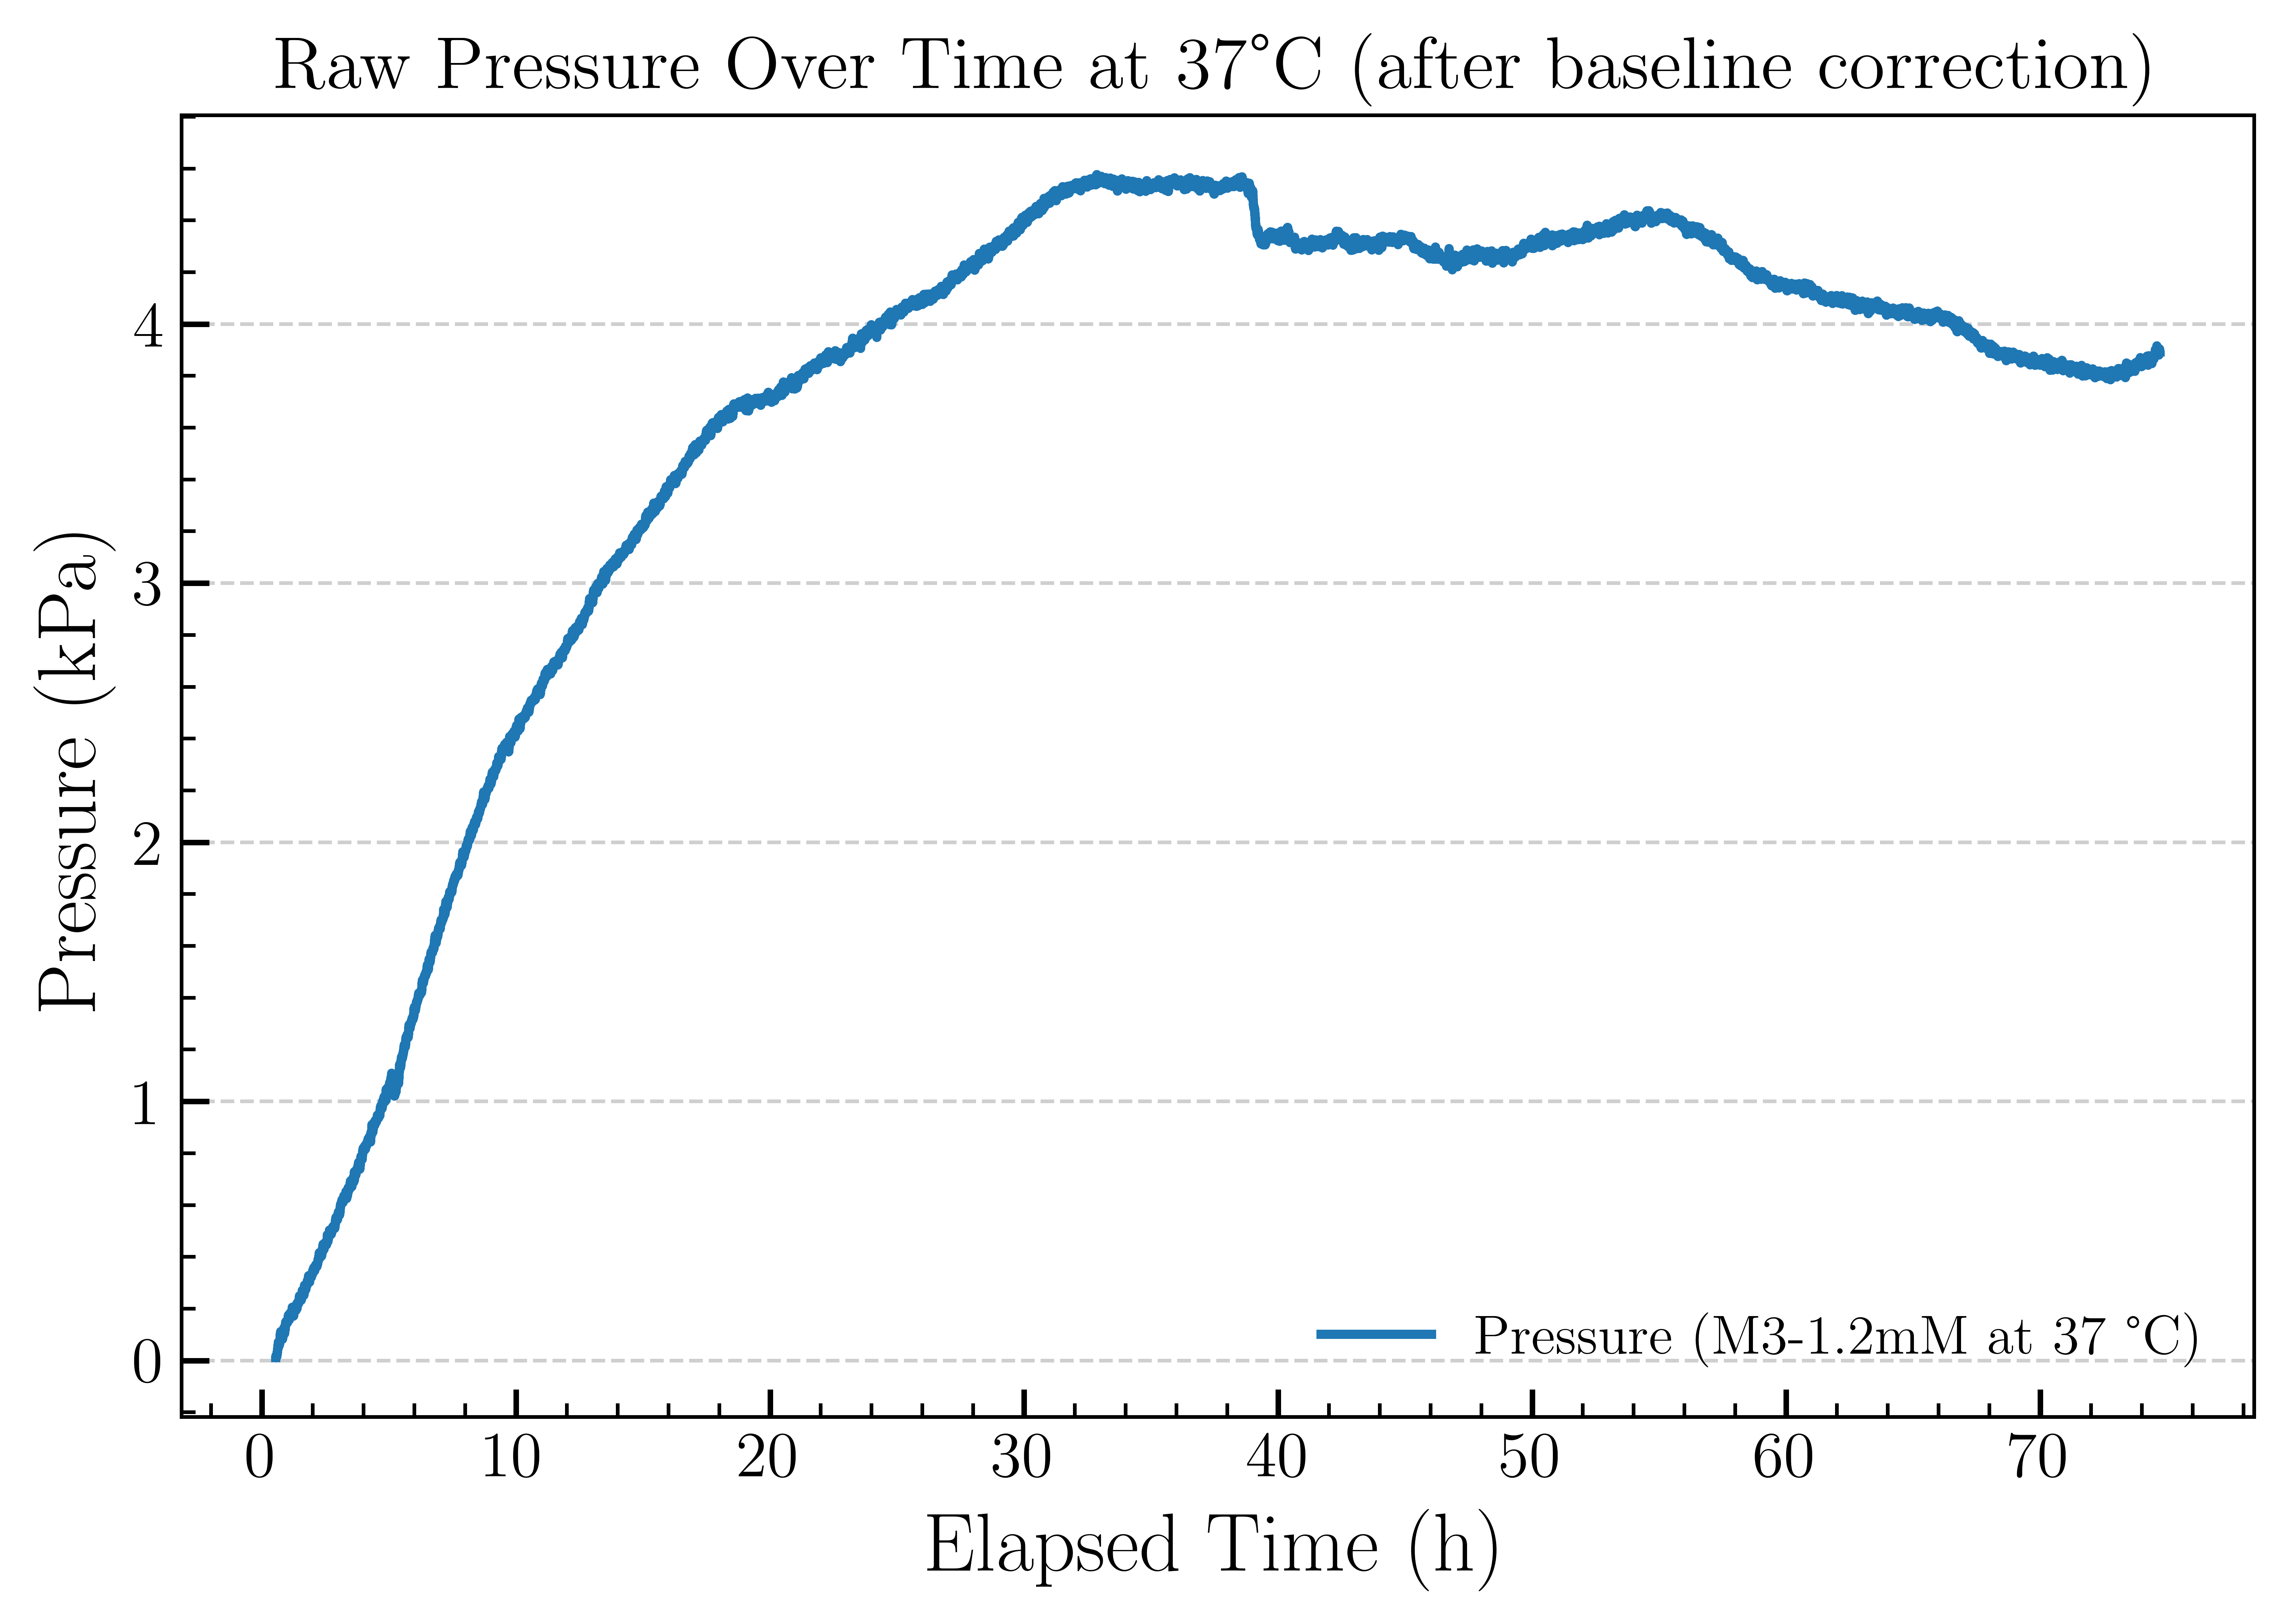

4.576708071748879


In [65]:
new_raw = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Sample_M3\M3_1.2mM\Pressure_37deg\raw_meas\raw_baseline5min_o2.csv"




# Load data
df_newraw = pd.read_csv(new_raw)

    

fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_newraw["Time (h)"],
         df_newraw["Raw pressure (baseline 5 min, kPa)"],
         lw=2.0, color="tab:blue",
         label=r'Pressure (M3-1.2mM at 37 °C)')

ax1.set_title('Raw Pressure Over Time at 37°C (after baseline correction)', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.show()

print(max(df_newraw["Raw pressure (baseline 5 min, kPa)"]))

# headspace o2 detected by sensor

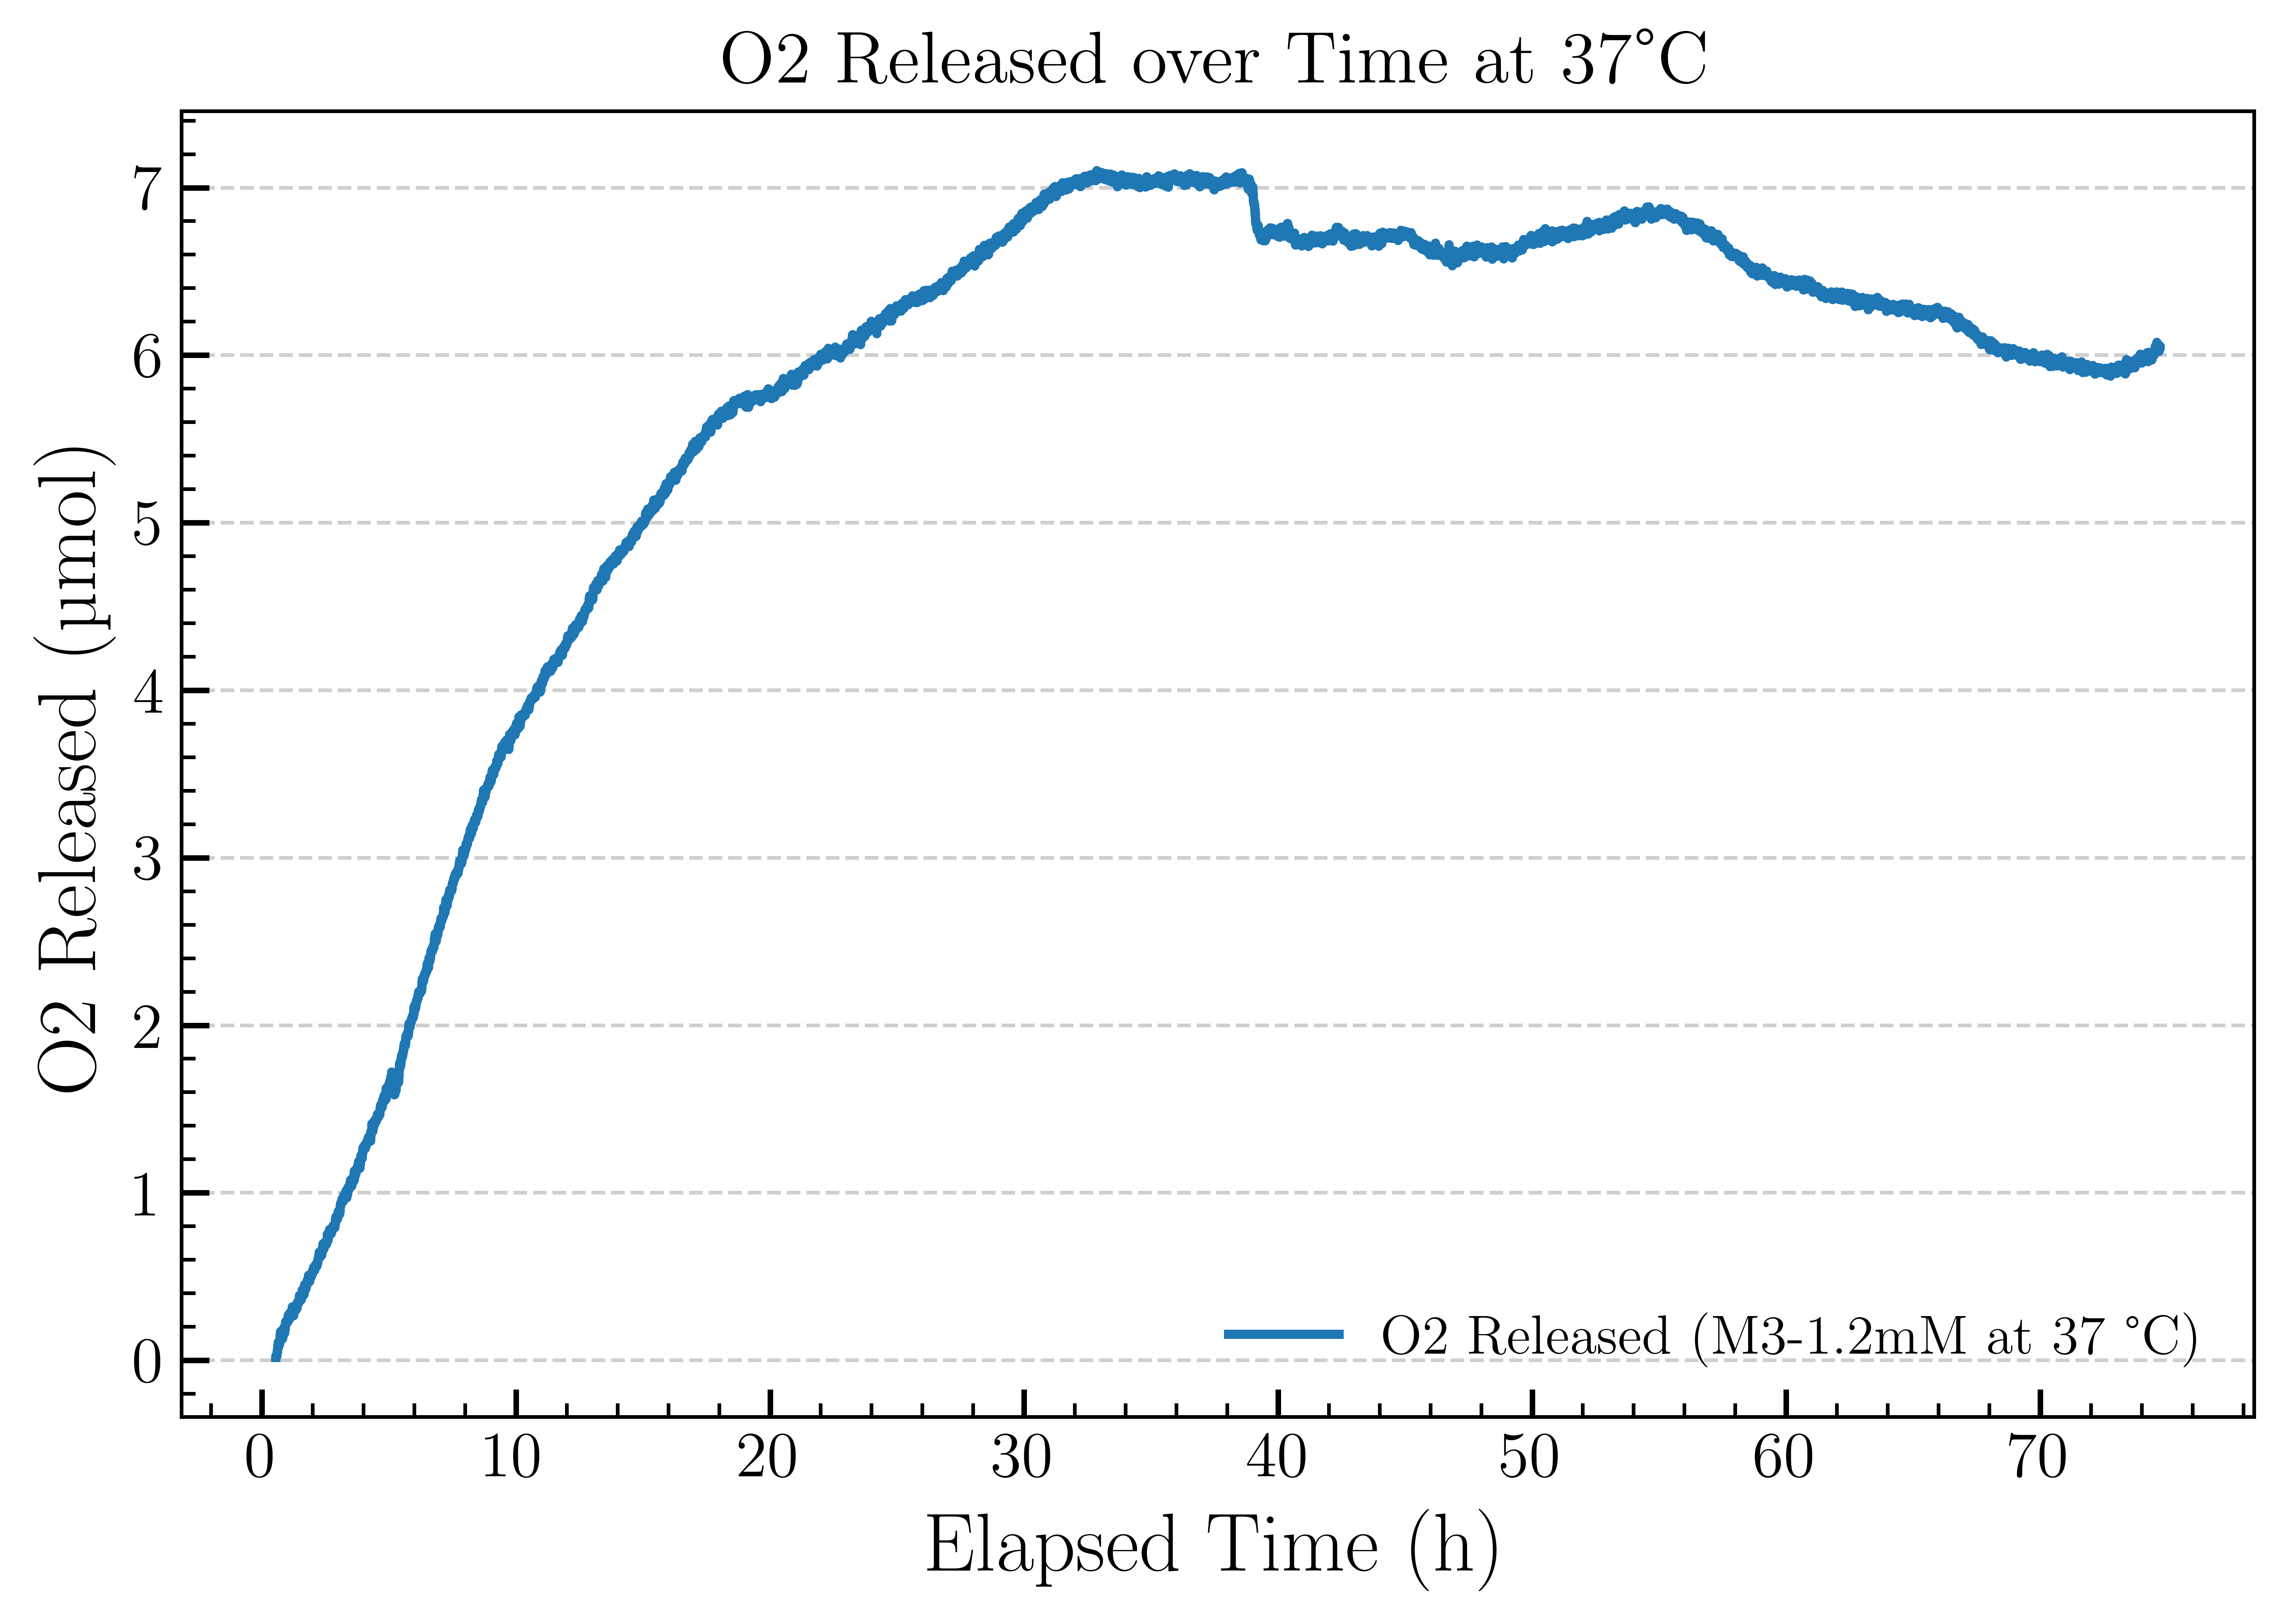

7.101256709821601


In [45]:
fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_newraw["Time (h)"],
         df_newraw["O2 Released (µmol)"],
         lw=2.0, color="tab:blue",
         label=r'O2 Released (M3-1.2mM at 37 °C)')

ax1.set_title('O2 Released over Time at 37°C', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="O2 Released (µmol)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.show()

print(max(df_newraw["O2 Released (µmol)"]))

# Just to see what is the max headspace value in smoothed and DWT

In [46]:
denoised_path = r"C:\Users\chand\Documents\GitHub\Thesis\M3_1.2mM_37deg_pressure_o2_release.csv"

denoised_main = pd.read_csv(denoised_path)

print("DWT max", max(denoised_main["DWT denoised pressure (kPa)"]))
print("SG max", max(denoised_main["Smoothed pressure from just SG (kPa)"]))
print("O2 max", max(denoised_main["O2 Released (µmol)"]))


DWT max 4.375260124630023
SG max 4.57756943912184
O2 max 6.790438988346479
